In [ ]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join("..")))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from src.utils import (
    check_convergence,
    compute_periodogram,
    plot_periodogram_log,
    plot_periodogram_normal,
    plot_mstl_decomposition,
    compute_seasonal_strength,
    plot_seasonal_correlation,
    plot_acf_pacf_residuals,
    COLOR_PRIMARY,
    COLOR_SECONDARY,
    COLOR_MEAN,
)

from src.preprocessing import (
    format_time_series,
    reindex_time_series,
    impute_time_series,
)

from src.mstl import mstl_fit_or_load

PLOT_TITLE_SIZE = 12
PLOT_LABEL_SIZE = 11

In [2]:
pjme = pd.read_csv("../data/raw/PJME_hourly.csv")

print("== Raw Dataset ==")
print(pjme.info())

== Raw Dataset ==
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype  
---  ------    --------------   -----  
 0   Datetime  145366 non-null  object 
 1   PJME_MW   145366 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.2+ MB
None


In [3]:
pjme = format_time_series(pjme)

print("== After Parsing & Renaming ==")
print(pjme.info())

== After Parsing & Renaming ==
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145366 entries, 0 to 145365
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  145366 non-null  datetime64[ns]
 1   energy    145366 non-null  float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 2.2 MB
None


In [4]:
print("== First 3 Rows ==")
print(pjme.head(3))

== First 3 Rows ==
             Datetime   energy
0 2002-12-31 01:00:00  26498.0
1 2002-12-31 02:00:00  25147.0
2 2002-12-31 03:00:00  24574.0


In [5]:
pjme = reindex_time_series(pjme)

== Date Range ==
Start: 2002-01-01 01:00:00
End:   2018-08-03 00:00:00
Expected hourly observations: 145,392
== Duplicate Timestamps: 4 ==
                      energy
Datetime                    
2014-11-02 02:00:00  23755.0
2015-11-01 02:00:00  21171.0
2016-11-06 02:00:00  21692.0
2017-11-05 02:00:00  20666.0
Rows after reindexing: 145,392


In [6]:
print("== Energy Consumption Summary ==")
print(pjme.describe())

== Energy Consumption Summary ==
              energy
count  145362.000000
mean    32080.505139
std      6463.874131
min     14544.000000
25%     27573.000000
50%     31421.000000
75%     35650.000000
max     62009.000000


In [7]:
check_convergence(pjme)
pjme = impute_time_series(pjme)


== Series Convergence Check ==
energy
1    30
Name: count, dtype: int64


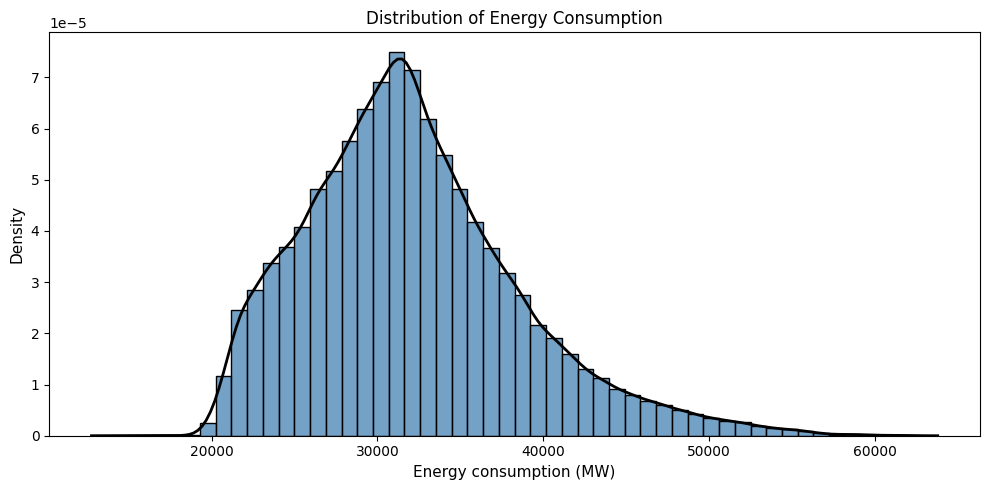

In [8]:
plt.figure(figsize=(10, 5))
sns.histplot(data=pjme["energy"], bins=50, stat="density", color=COLOR_PRIMARY)
sns.kdeplot(data=pjme["energy"], color=COLOR_MEAN, linewidth=2.0)
plt.title("Distribution of Energy Consumption", fontsize=PLOT_TITLE_SIZE)
plt.xlabel("Energy consumption (MW)", fontsize=PLOT_LABEL_SIZE)
plt.ylabel("Density", fontsize=PLOT_LABEL_SIZE)
plt.tight_layout()
plt.show()

In [9]:
energy_skew = pjme["energy"].skew()
energy_kurtosis = pjme["energy"].kurt()

print("== Distribution Shape ==")
print(f"Skewness: {energy_skew:.4f}")
print(f"Kurtosis: {energy_kurtosis:.4f}")

== Distribution Shape ==
Skewness: 0.7390
Kurtosis: 0.7365


In [10]:
pjme["hour"] = pjme.index.hour
pjme["dayofweek"] = pjme.index.dayofweek
pjme["month"] = pjme.index.month

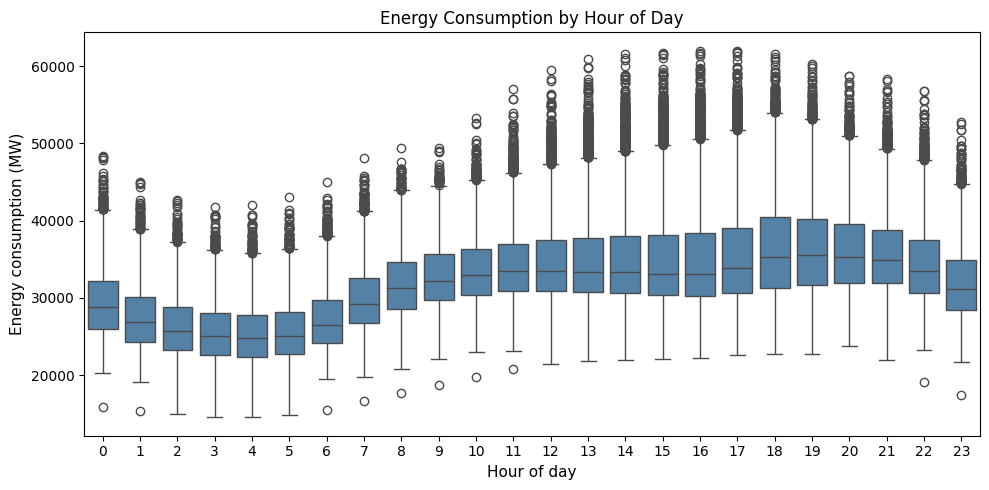

In [11]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=pjme, x="hour", y="energy", color=COLOR_PRIMARY)
plt.title("Energy Consumption by Hour of Day", fontsize=PLOT_TITLE_SIZE)
plt.xlabel("Hour of day", fontsize=PLOT_LABEL_SIZE)
plt.ylabel("Energy consumption (MW)", fontsize=PLOT_LABEL_SIZE)
plt.tight_layout()
plt.show()

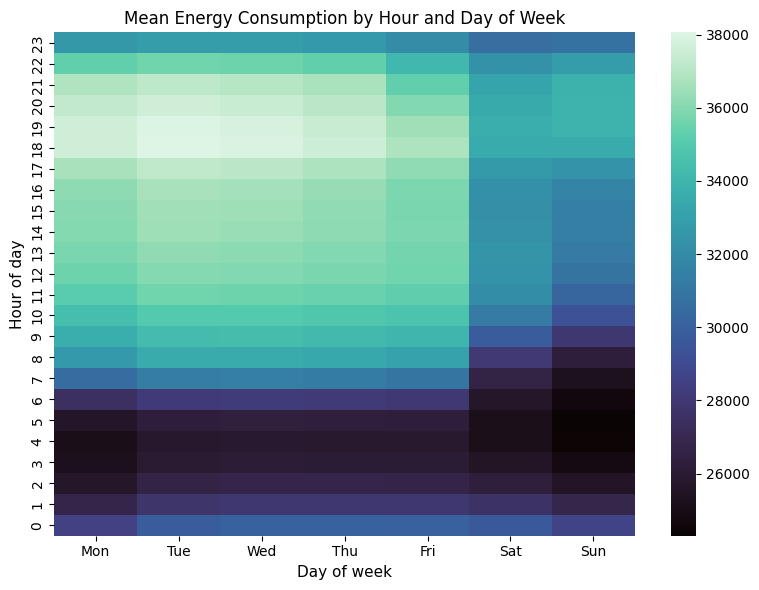

In [12]:
mean_energy_hour_dow = pd.pivot_table(
    data=pjme, index="hour", columns="dayofweek", values="energy", aggfunc="mean"
).sort_index(ascending=False)

day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

plt.figure(figsize=(8, 6))
ax = sns.heatmap(mean_energy_hour_dow, cmap="mako")
ax.set_xticklabels(day_labels)
ax.set_xlabel("Day of week", fontsize=PLOT_LABEL_SIZE)
ax.set_ylabel("Hour of day", fontsize=PLOT_LABEL_SIZE)
ax.set_title(
    "Mean Energy Consumption by Hour and Day of Week", fontsize=PLOT_TITLE_SIZE
)
plt.tight_layout()
plt.show()

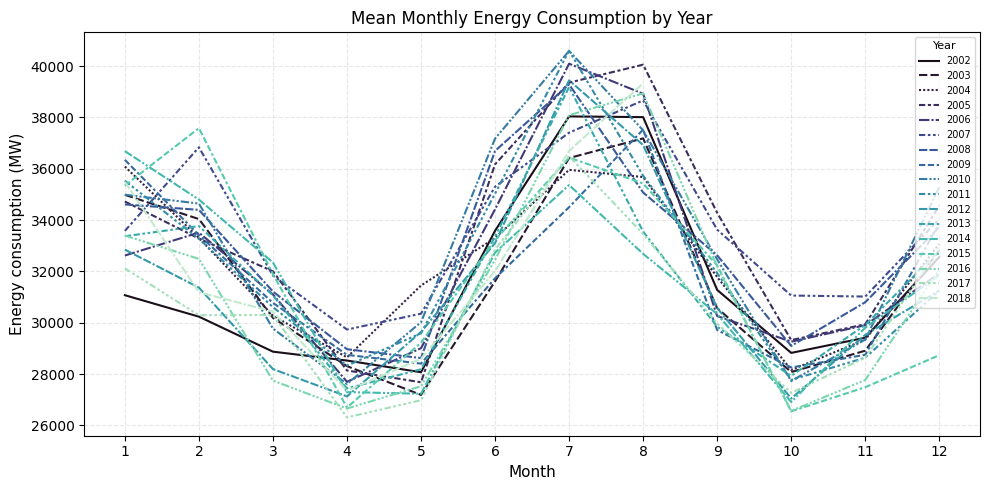

In [13]:
mean_energy_by_month = pjme[["energy"]].pivot_table(
    index=pjme.index.month, columns=pjme.index.year, values="energy", aggfunc="mean"
)

plt.figure(figsize=(10, 5))
sns.lineplot(data=mean_energy_by_month, lw=1.5, palette="mako")
plt.title("Mean Monthly Energy Consumption by Year", fontsize=PLOT_TITLE_SIZE)
plt.xticks(range(1, 13))
plt.xlabel("Month", fontsize=PLOT_LABEL_SIZE)
plt.ylabel("Energy consumption (MW)", fontsize=PLOT_LABEL_SIZE)
plt.legend(title="Year", fontsize=7, title_fontsize=8, loc="upper right")
plt.grid(True, alpha=0.3, linestyle="--")
plt.tight_layout()
plt.show()

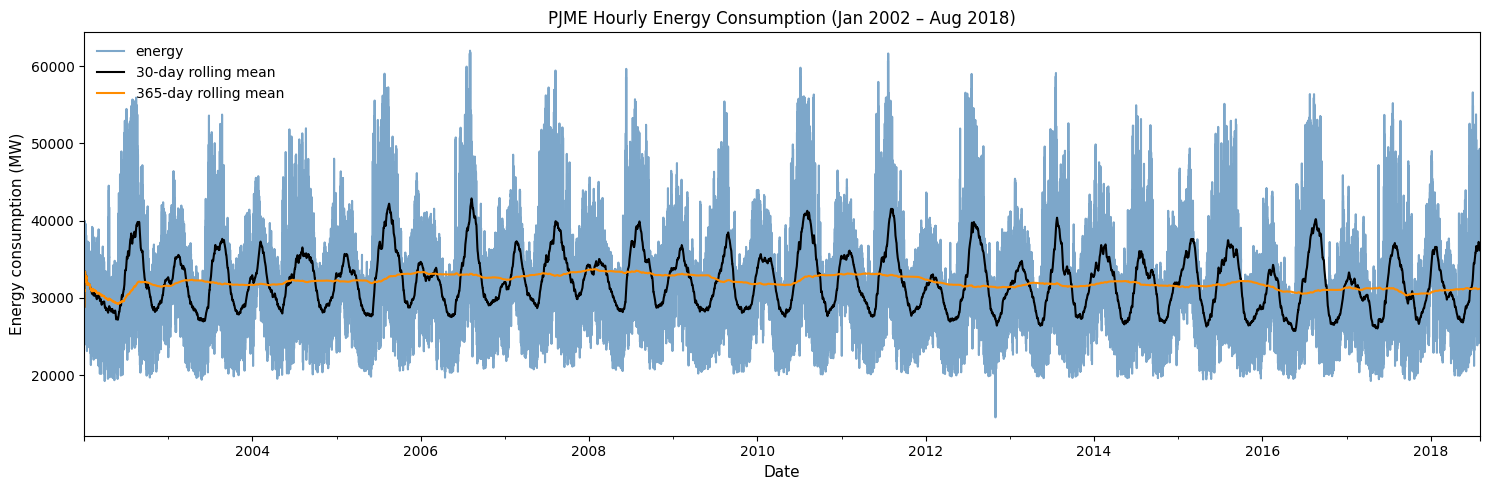

In [14]:
fig, ax = plt.subplots(figsize=(15, 5))
pjme["energy"].plot(ax=ax, legend=False, alpha=0.7, color=COLOR_PRIMARY)
pjme["energy"].rolling("30D").mean().plot(
    ax=ax, legend=True, label="30-day rolling mean", color=COLOR_MEAN, lw=1.5
)
pjme["energy"].rolling("365D").mean().plot(
    ax=ax, legend=True, label="365-day rolling mean", lw=1.5, color=COLOR_SECONDARY
)

ax.set_title(
    "PJME Hourly Energy Consumption (Jan 2002 – Aug 2018)",
    fontsize=PLOT_TITLE_SIZE,
)
ax.set_ylabel("Energy consumption (MW)", fontsize=PLOT_LABEL_SIZE)
ax.set_xlabel("Date", fontsize=PLOT_LABEL_SIZE)
ax.legend(loc="upper left", frameon=False)
plt.tight_layout()
plt.show()

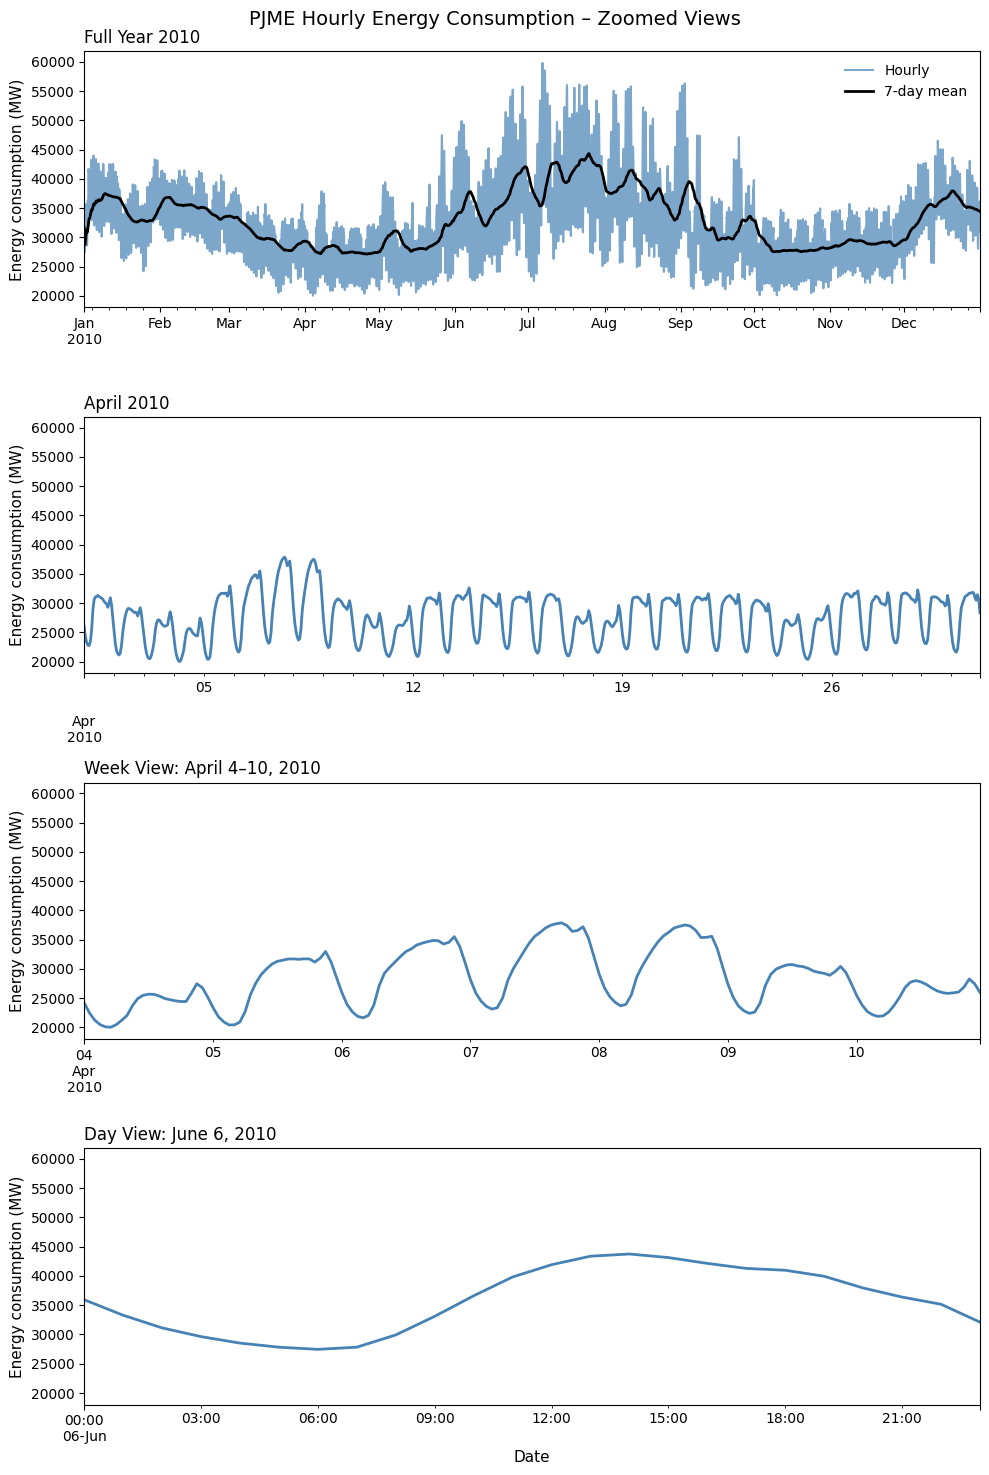

In [15]:
fig, axes = plt.subplots(4, 1, figsize=(10, 15), sharey=True)
fig.suptitle(
    "PJME Hourly Energy Consumption – Zoomed Views",
    fontsize=14,
)

pjme["energy"].loc["2010"].plot(
    ax=axes[0], alpha=0.7, label="Hourly", color=COLOR_PRIMARY
)
pjme["energy"].loc["2010"].rolling("7D").mean().plot(
    ax=axes[0], color=COLOR_MEAN, lw=2, label="7-day mean"
)
axes[0].set_title("Full Year 2010", fontsize=PLOT_TITLE_SIZE, loc="left")
axes[0].legend(loc="upper right", frameon=False)

pjme["energy"].loc["2010-04-01":"2010-04-30"].plot(
    ax=axes[1], lw=2.0, color=COLOR_PRIMARY
)
axes[1].set_title("April 2010", fontsize=PLOT_TITLE_SIZE, loc="left")

pjme["energy"].loc["2010-04-04":"2010-04-10"].plot(
    ax=axes[2], lw=2.0, color=COLOR_PRIMARY
)
axes[2].set_title("Week View: April 4–10, 2010", fontsize=PLOT_TITLE_SIZE, loc="left")

pjme["energy"].loc["2010-06-06"].plot(ax=axes[3], lw=2, color=COLOR_PRIMARY)
axes[3].set_title("Day View: June 6, 2010", fontsize=PLOT_TITLE_SIZE, loc="left")

axes[-1].set_xlabel("Date", fontsize=PLOT_LABEL_SIZE)
for ax in axes:
    ax.set_ylabel("Energy consumption (MW)", fontsize=PLOT_LABEL_SIZE)

plt.tight_layout()
plt.show()

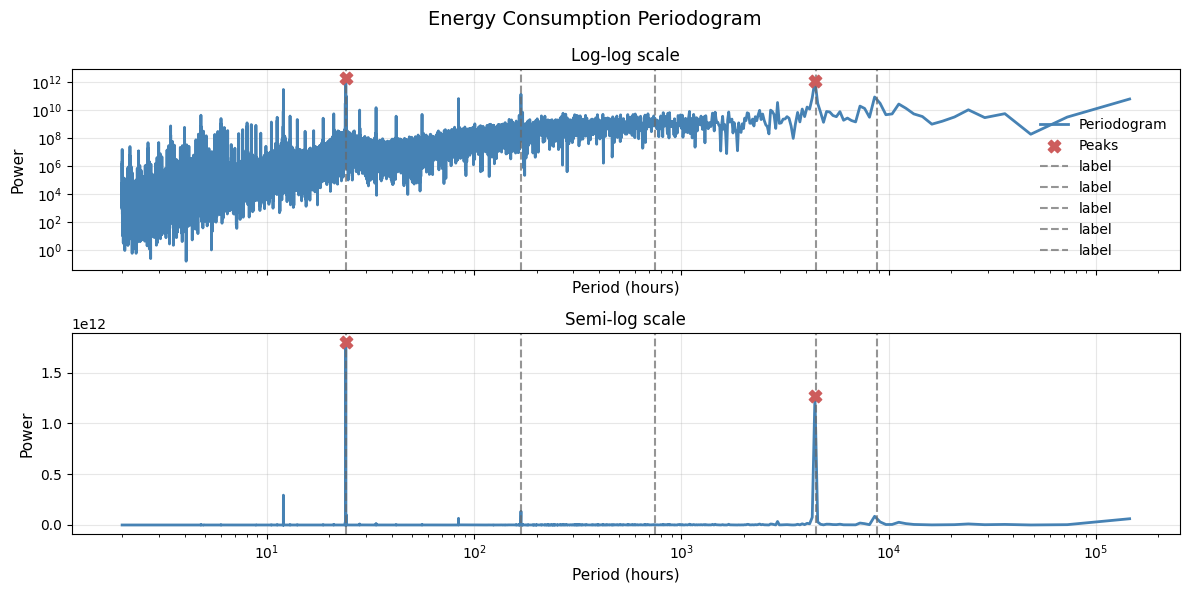

In [16]:
periods, psd, peak_idx = compute_periodogram(pjme["energy"])

plot_periodogram_log(periods, psd, peak_idx)

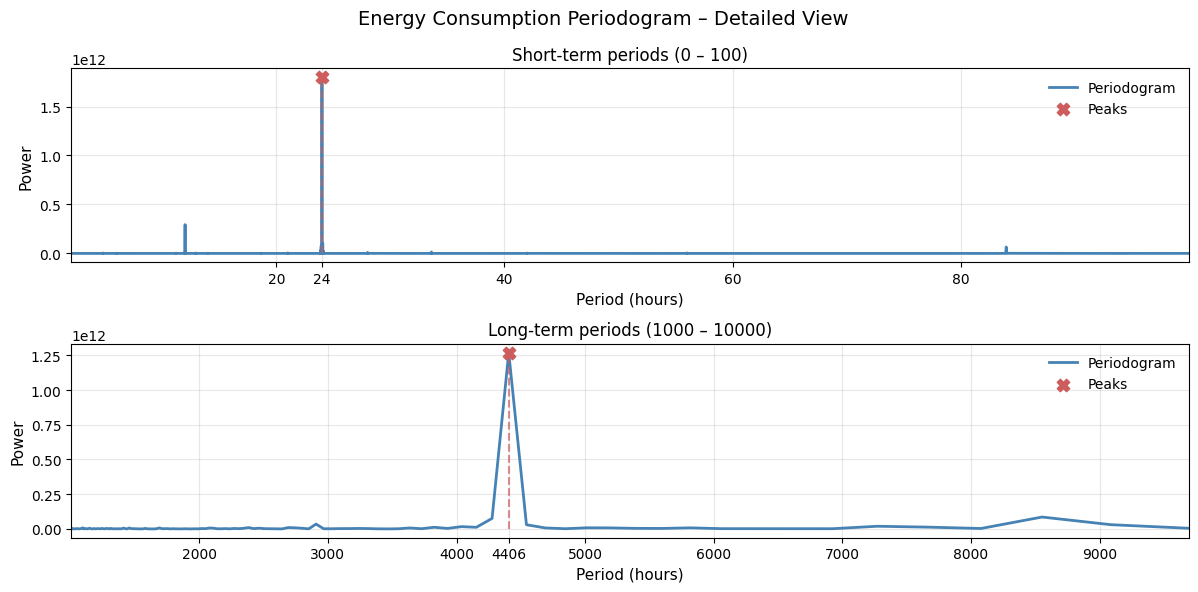

In [17]:
plot_periodogram_normal(periods, psd, peak_idx, [0, 100], [1000, 10000])

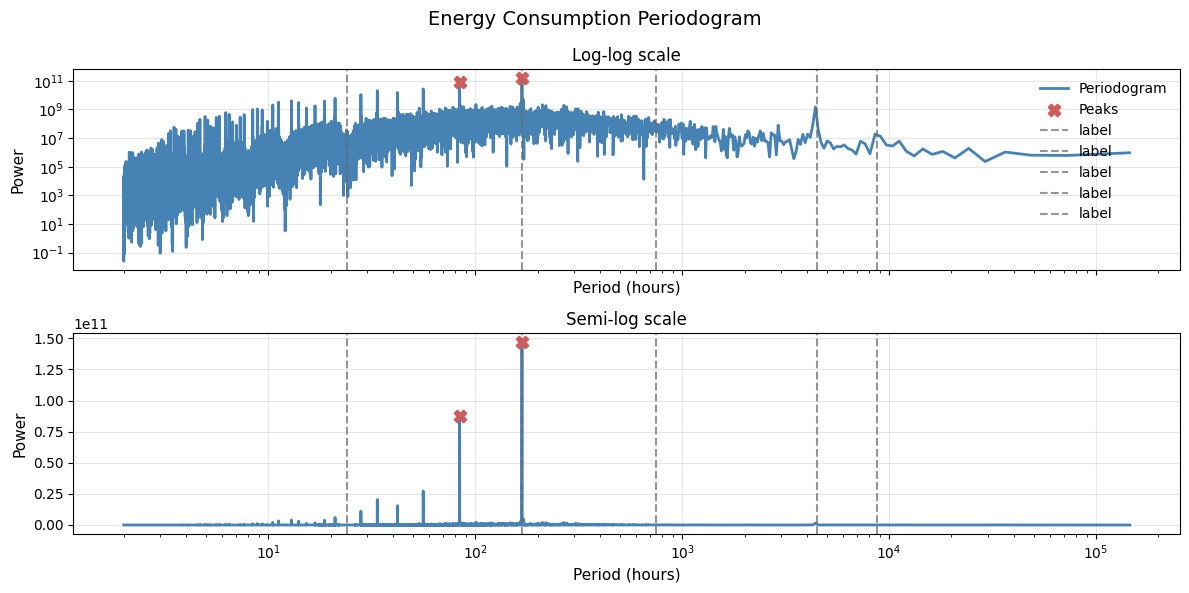

In [18]:
diff_24h = pjme["energy"].diff(24).dropna()
periods, psd, peak_idx = compute_periodogram(diff_24h)

plot_periodogram_log(periods, psd, peak_idx)

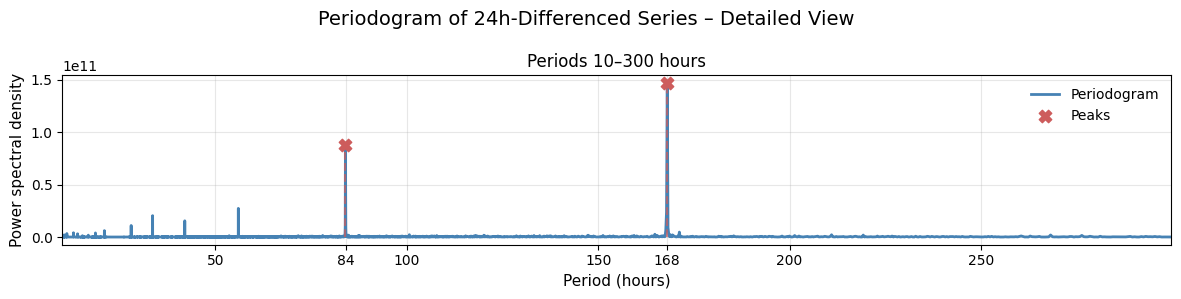

In [19]:
plot_periodogram_normal(
    periods,
    psd,
    peak_idx,
    short_idx=[10, 300],
    fig_title="Periodogram of 24h-Differenced Series – Detailed View",
    short_title="Periods 10–300 hours",
    ylabel="Power spectral density",
)

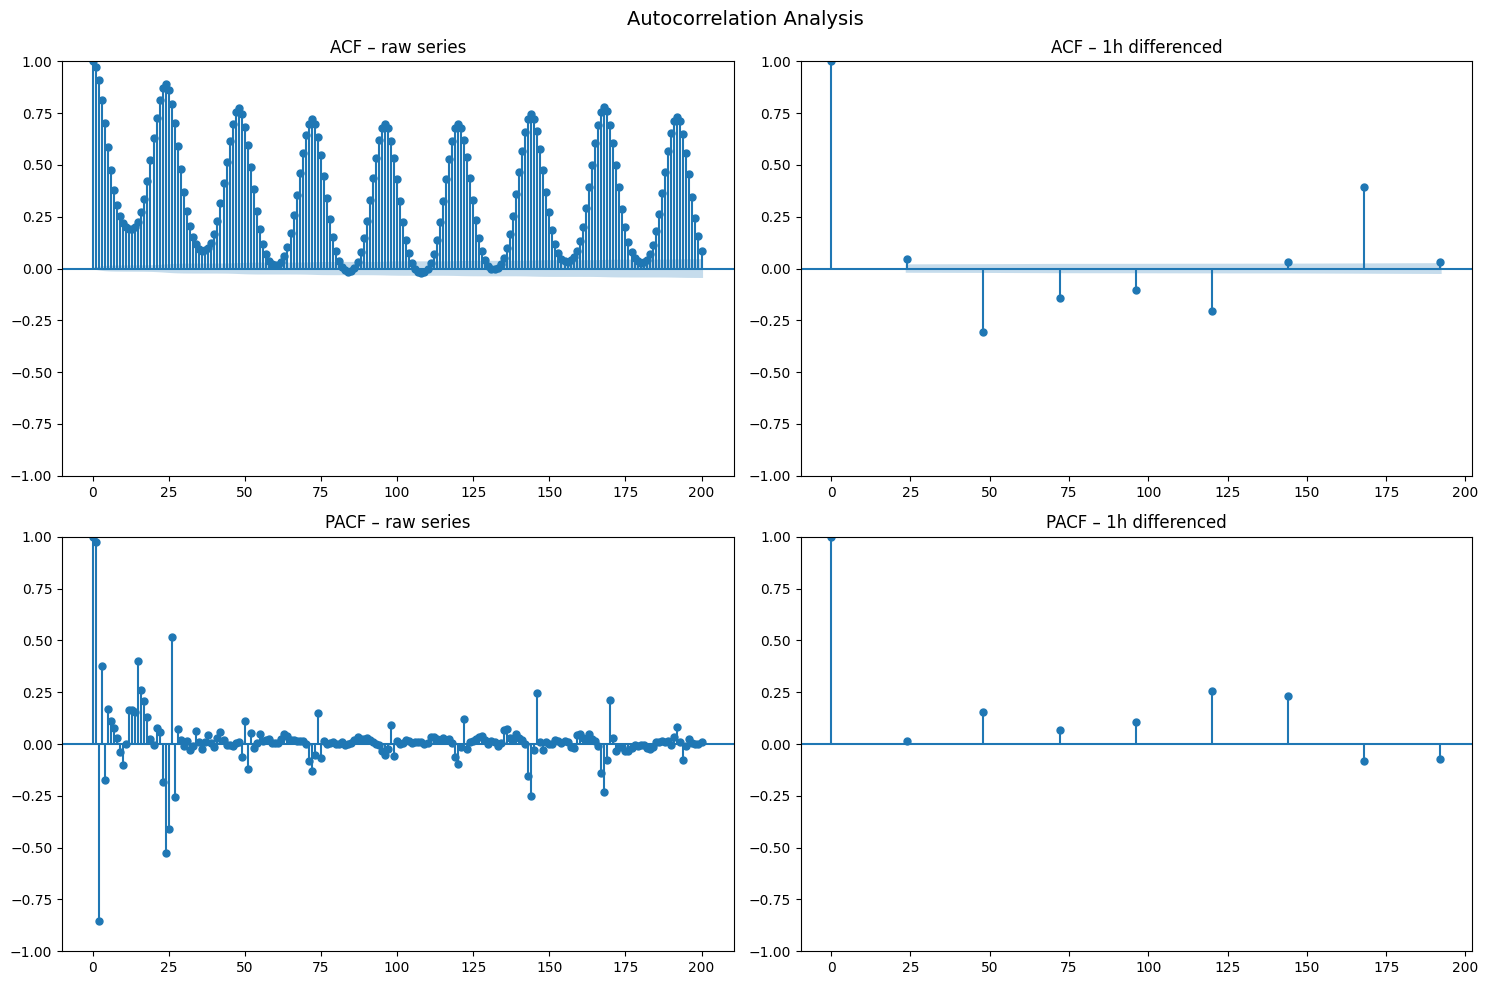

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

plot_acf(pjme["energy"], lags=200, alpha=0.05, ax=axes[0, 0])
axes[0, 0].set_title("ACF – raw series", fontsize=PLOT_TITLE_SIZE)

plot_pacf(pjme["energy"], lags=200, alpha=0.05, ax=axes[1, 0])
axes[1, 0].set_title("PACF – raw series", fontsize=PLOT_TITLE_SIZE)

plot_acf(
    pjme["energy"].diff(24).dropna(),
    lags=np.arange(0, 216, 24),
    alpha=0.05,
    ax=axes[0, 1],
)
axes[0, 1].set_title("ACF – 1h differenced", fontsize=PLOT_TITLE_SIZE)

plot_pacf(
    pjme["energy"].diff(24).dropna(),
    lags=np.arange(0, 216, 24),
    alpha=0.05,
    ax=axes[1, 1],
)
axes[1, 1].set_title("PACF – 1h differenced", fontsize=PLOT_TITLE_SIZE)

fig.suptitle("Autocorrelation Analysis", fontsize=14)
plt.tight_layout()
plt.show()

[CACHE] File ../models/mstl_full_24_84_168_4406.parquet already exists. Loading results..


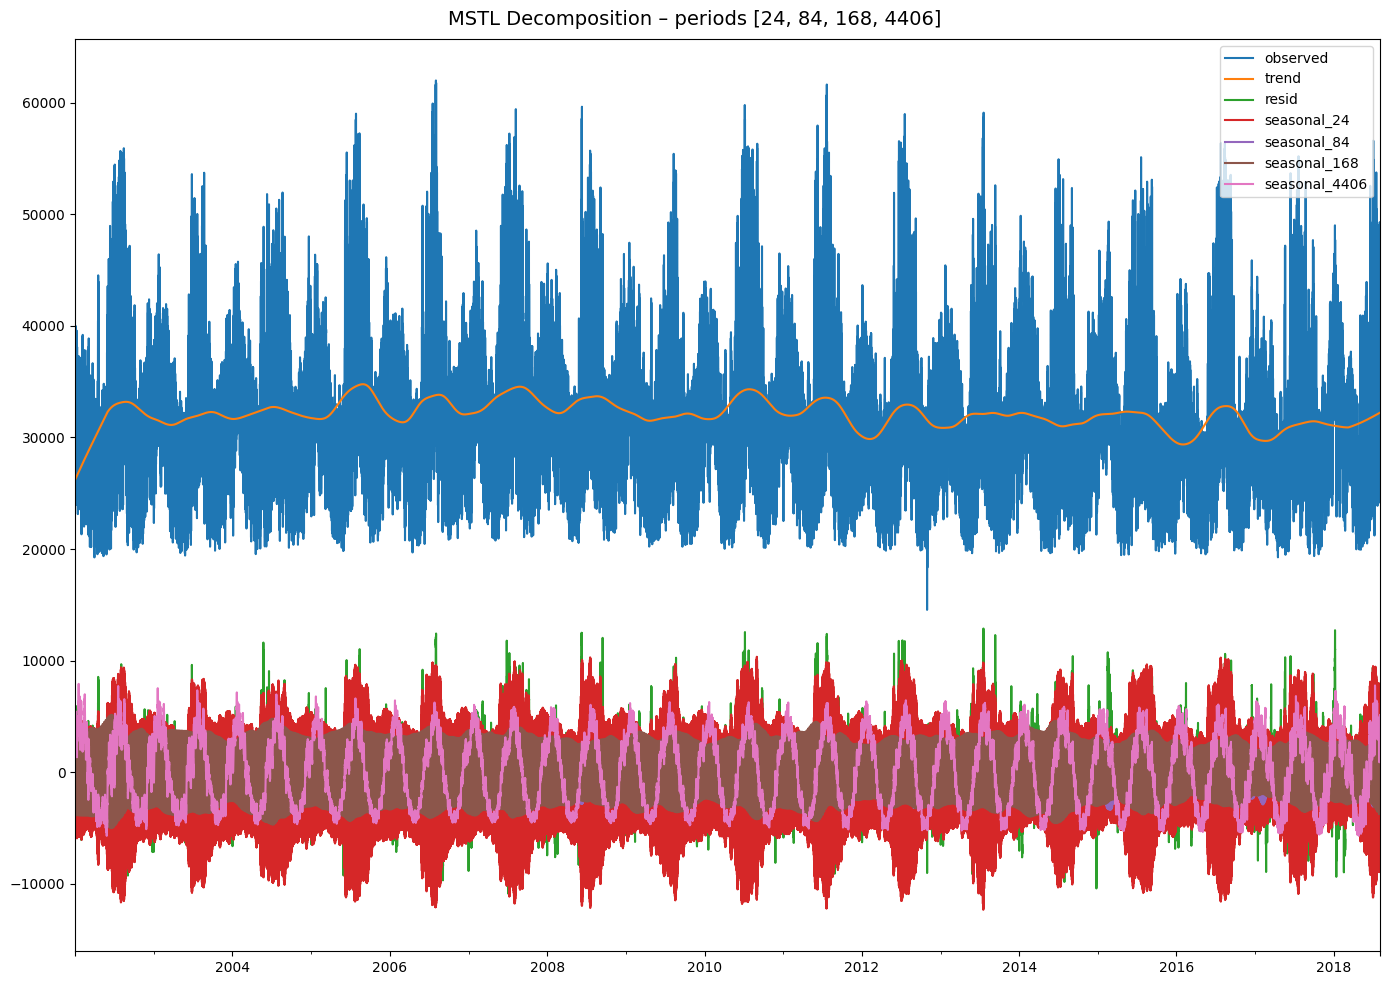

In [21]:
MSTL_PERIODS = [24, 84, 168, 4406]
decomp = mstl_fit_or_load(pjme["energy"], MSTL_PERIODS, split_name="full")

plot_mstl_decomposition(decomp, MSTL_PERIODS)

== Hyndman's Seasonal Strength (periods [24, 84, 168, 4406]) ==
  seasonal_24: 0.7067
  seasonal_84: 0.1256
  seasonal_168: 0.2466
  seasonal_4406: 0.5894


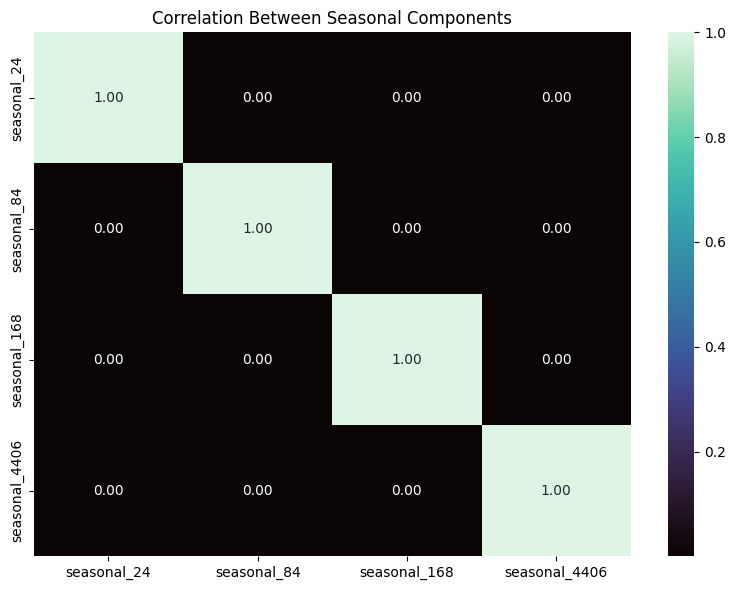

In [22]:
print("== Hyndman's Seasonal Strength (periods [24, 84, 168, 4406]) ==")
for season, strength in compute_seasonal_strength(decomp).items():
    print(f"  {season}: {strength:.4f}")

plot_seasonal_correlation(decomp)

[CACHE] File ../models/mstl_full_24_168_4406.parquet already exists. Loading results..


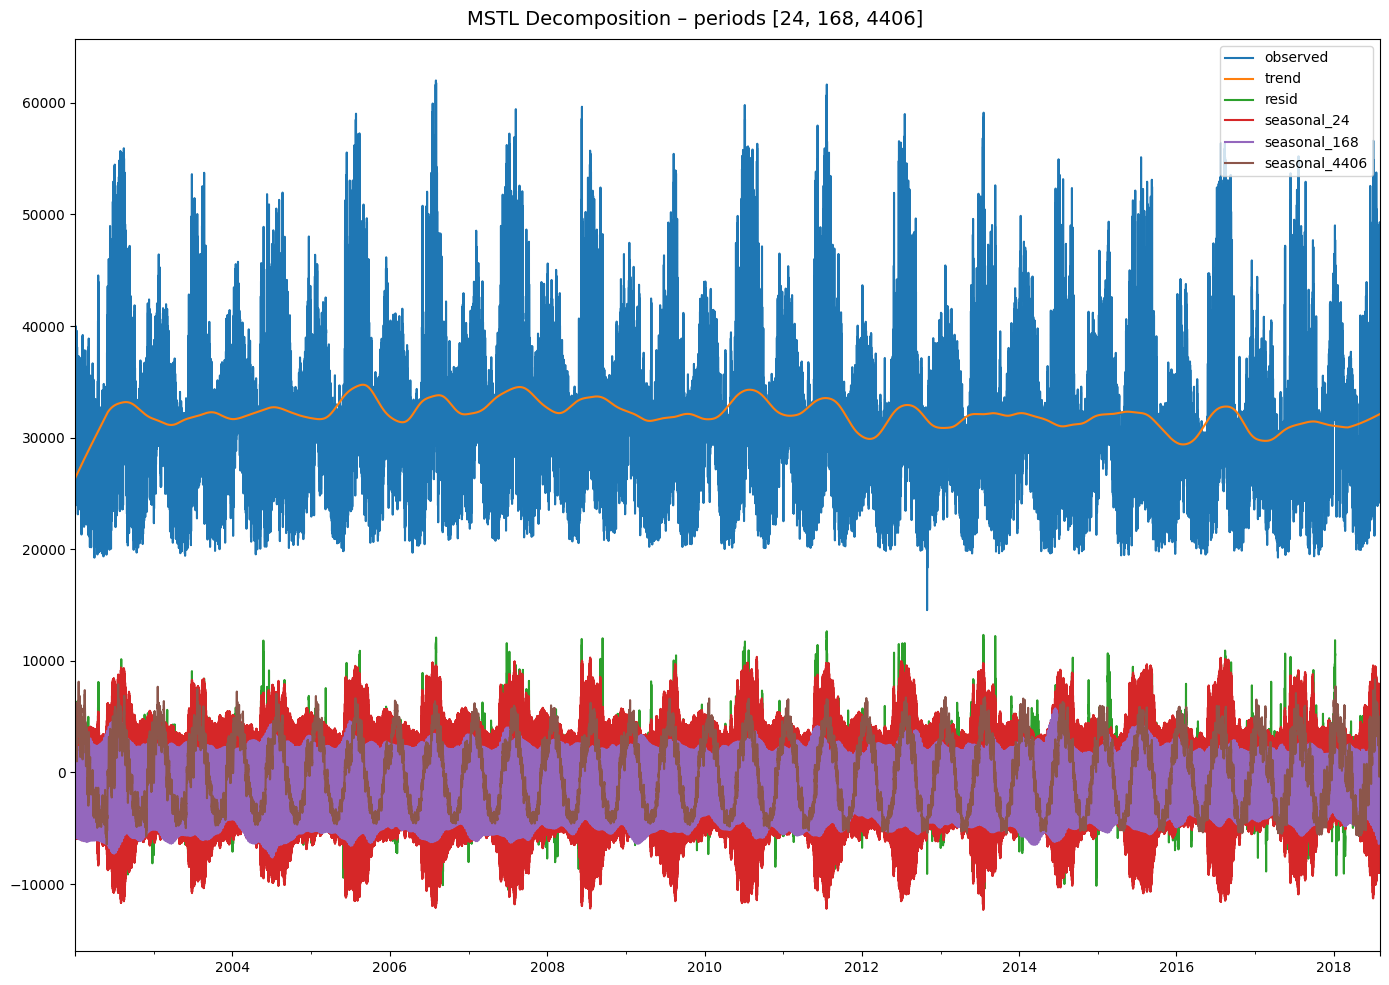

In [23]:
MSTL_PERIODS = [24, 168, 4406]
decomp = mstl_fit_or_load(pjme["energy"], MSTL_PERIODS, split_name="full")

plot_mstl_decomposition(decomp, MSTL_PERIODS)

== Hyndman's Seasonal Strength (periods [24, 84, 168, 4406]) ==
  seasonal_24: 0.7107
  seasonal_168: 0.3208
  seasonal_4406: 0.5989


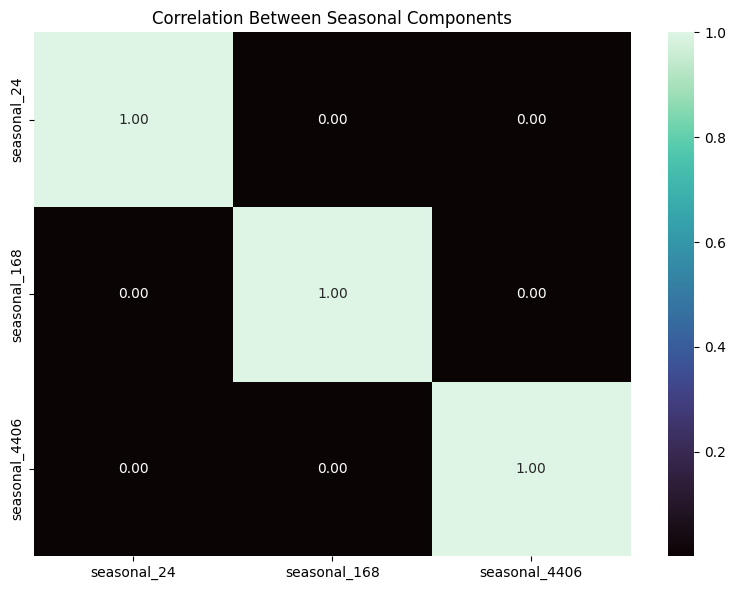

In [24]:
print("== Hyndman's Seasonal Strength (periods [24, 84, 168, 4406]) ==")
for season, strength in compute_seasonal_strength(decomp).items():
    print(f"  {season}: {strength:.4f}")

plot_seasonal_correlation(decomp)

[CACHE] File ../models/mstl_full_24_168_4406_8766.parquet already exists. Loading results..


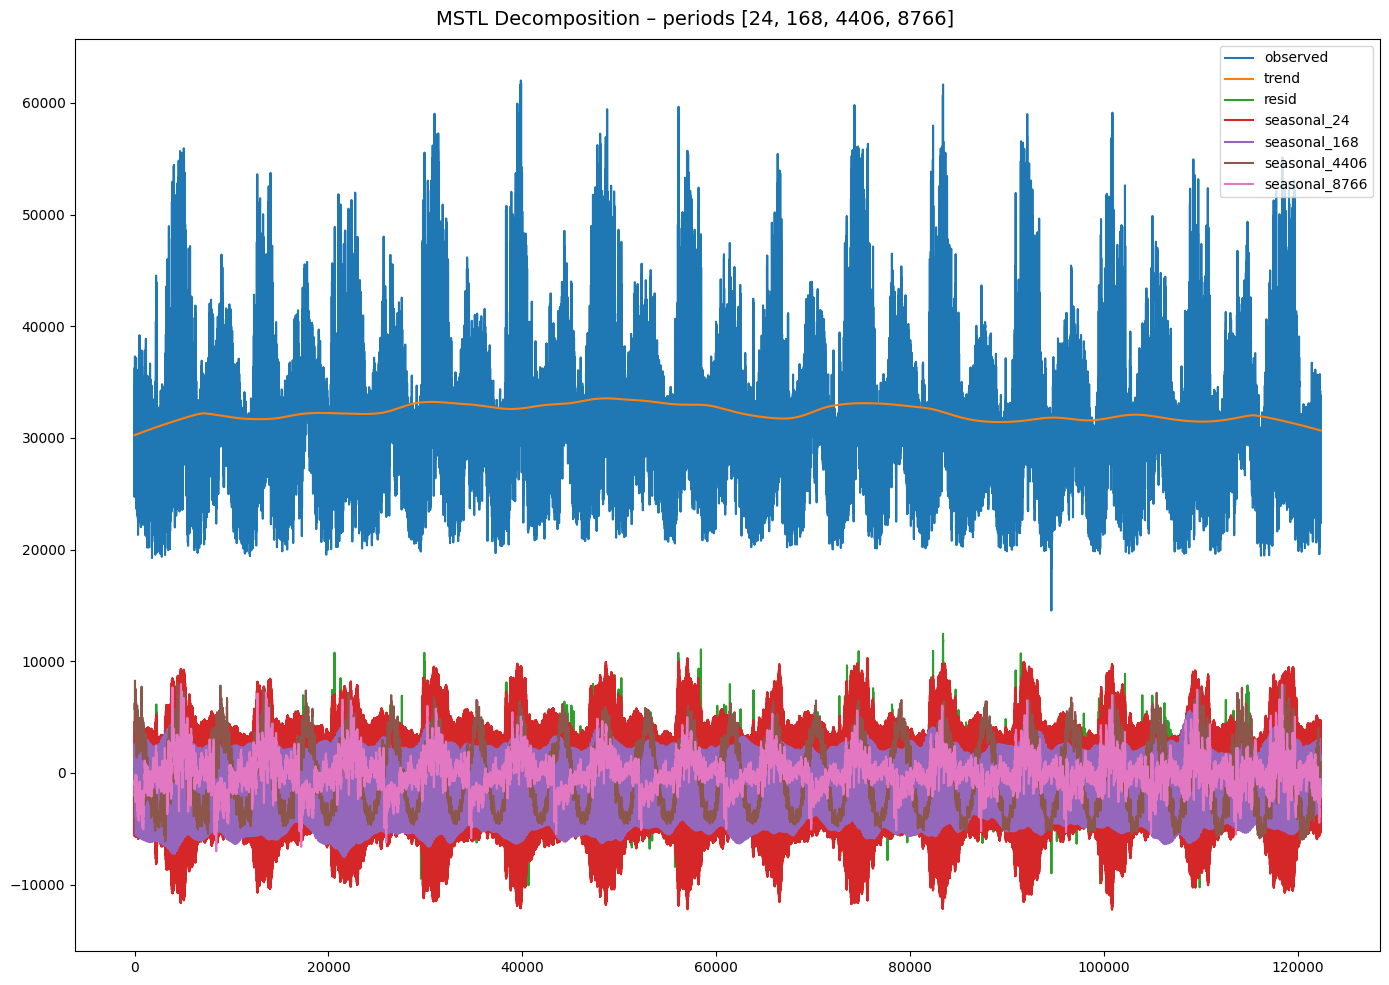

In [25]:
MSTL_PERIODS_ALT = [24, 168, 4406, 8766]
decomp_alt = mstl_fit_or_load(pjme["energy"], MSTL_PERIODS_ALT, split_name="full")

plot_mstl_decomposition(decomp_alt, MSTL_PERIODS_ALT)

== Hyndman's Seasonal Strength (periods [24, 168, 4406, 8766]) ==
  seasonal_24: 0.7622
  seasonal_168: 0.3850
  seasonal_4406: 0.6511
  seasonal_8766: 0.2999


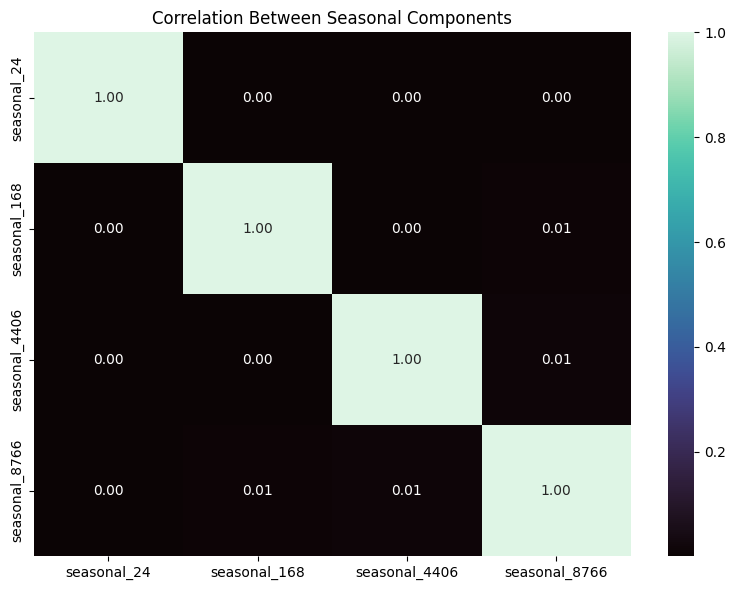

In [26]:
print("== Hyndman's Seasonal Strength (periods [24, 168, 4406, 8766]) ==")
for season, strength in compute_seasonal_strength(decomp_alt).items():
    print(f"  {season}: {strength:.4f}")

plot_seasonal_correlation(decomp_alt)

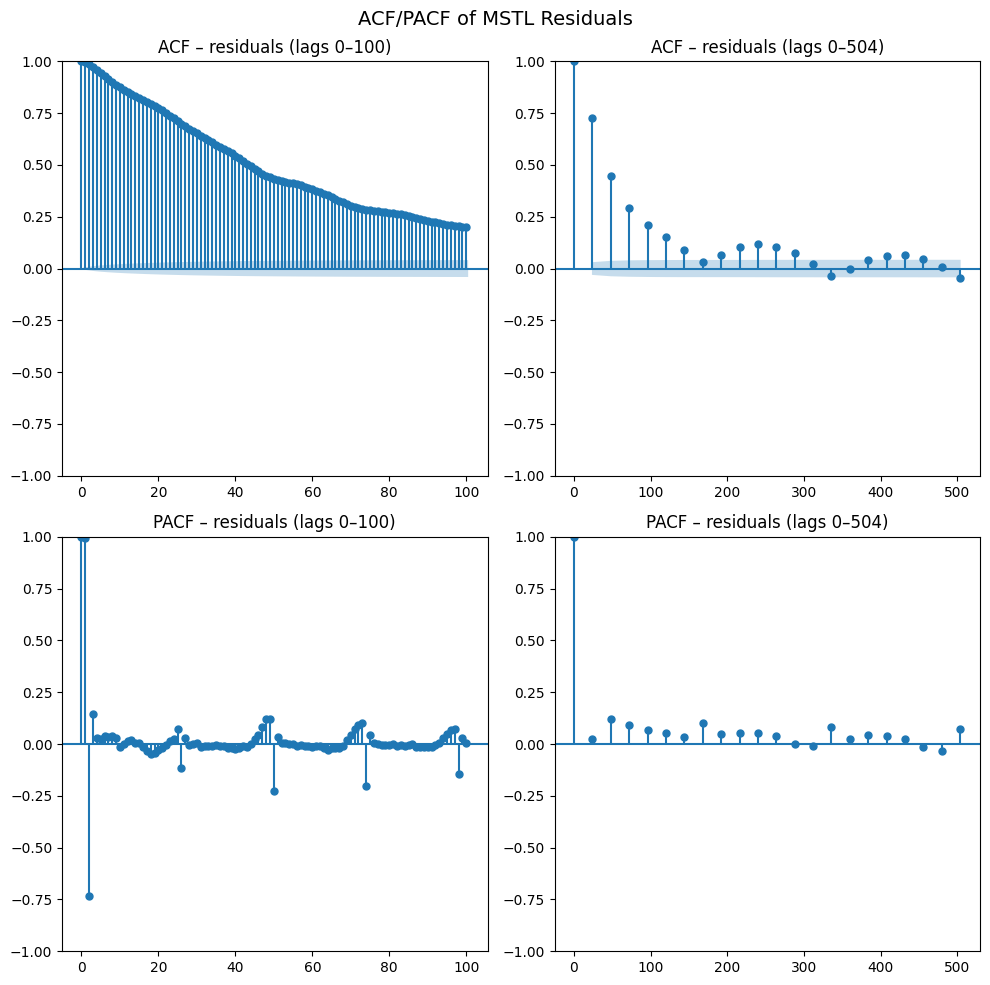

In [27]:
plot_acf_pacf_residuals(decomp.resid, fig_title="ACF/PACF of MSTL Residuals")